# 1. Importar Librerías Necesarias
Cargamos las librerías principales para procesamiento de imágenes, TensorFlow y manipulación de datos.

In [ ]:

import os
import cv2
import numpy as np
import tensorflow as tf
from tqdm import tqdm
from sklearn.model_selection import train_test_split

# 2. Verificar GPU
Verificamos si TensorFlow puede acceder a la GPU disponible.

In [23]:
import cv2
import numpy as np

IMG_SIZE = 224
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

def procesar_imagen(ruta):
    # 1. Leer en escala de grises (1 canal)
    img = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)

    if img is None:
        return None

    # 2. Resize
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # 3. Reducir ruido (importante antes del CLAHE)
    img = cv2.GaussianBlur(img, (3, 3), 0)

    # 4. Mejorar contraste (CLAHE es superior a equalizeHist para médicas)
    img = clahe.apply(img)

    # 5. Convertir a RGB (ResNet50 requiere los 3 canales)
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

    return img

# 3. Función de Procesamiento de Imágenes
Define la función para procesar cada imagen: redimensionar, reducir ruido, mejorar contraste y normalizar.

In [24]:
def cargar_dataset(ruta_dataset):
    X = []
    y = []

    clases = ["cancer", "no_cancer"]

    for idx, clase in enumerate(clases):
        ruta_clase = os.path.join(ruta_dataset, clase)

        print(f"Cargando {clase}...")

        for img_nombre in tqdm(os.listdir(ruta_clase)):
            ruta_img = os.path.join(ruta_clase, img_nombre)

            img = procesar_imagen(ruta_img)

            if img is not None:
                X.append(img)
                y.append(idx)

    return np.array(X), np.array(y)

# 4. Función para Cargar Dataset
Define la función que carga todas las imágenes del dataset y aplica el procesamiento a cada una.

In [25]:
ruta_dataset = "dataset_expandido"

X, y = cargar_dataset(ruta_dataset)

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Cargando cancer...


100%|██████████| 5688/5688 [00:20<00:00, 278.25it/s]


Cargando no_cancer...


100%|██████████| 5256/5256 [00:25<00:00, 203.00it/s]


Shape X: (10944, 224, 224, 3)
Shape y: (10944,)


# 5. Cargar Dataset Original
Cargar todas las imágenes del dataset original y mostrar sus dimensiones.

In [26]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (7660, 224, 224, 3)
Val: (1642, 224, 224, 3)
Test: (1642, 224, 224, 3)


# 6. Dividir Dataset en Train, Validación y Test
Dividir los datos: 70% entrenamiento, 15% validación, 15% test.

In [27]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

# 7. Configurar Data Augmentation
Define técnicas de aumentación de datos: rotaciones, zoom y flips para mejorar generalización.

In [28]:
import tensorflow as tf
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 8. Importar Librerías Adicionales para Métricas
Importar librerías para visualización, métricas de evaluación y análisis de resultados.

In [29]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)

Class weights: {0: 0.9620698317005777, 1: 1.0410437618918185}


# 9. Calcular Pesos de Clases
Calcular pesos automáticos para balancear clases desbalanceadas en el dataset.

In [30]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

# 10. Crear Datasets de TensorFlow
Crear datasets optimizados para TensorFlow con batches y aplicar data augmentation al conjunto de entrenamiento.

In [31]:
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = train_dataset.shuffle(1000).batch(BATCH_SIZE)
train_dataset = train_dataset.map(
    lambda x, y: (tf.cast(data_augmentation(x, training=True), tf.float32), tf.cast(y, tf.int32)),
    num_parallel_calls=AUTOTUNE
)
train_dataset = train_dataset.prefetch(AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE)
val_dataset = val_dataset.map(
    lambda x, y: (tf.cast(x, tf.float32), tf.cast(y, tf.int32)),
    num_parallel_calls=AUTOTUNE
)
val_dataset = val_dataset.prefetch(AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE)
test_dataset = test_dataset.map(
    lambda x, y: (tf.cast(x, tf.float32), tf.cast(y, tf.int32)),
    num_parallel_calls=AUTOTUNE
)
test_dataset = test_dataset.prefetch(AUTOTUNE)

# 11. Construir Modelo

In [ ]:
from tensorflow.keras import layers, models

def crear_cnn_personalizada(input_shape=(224, 224, 3), num_clases=2):
    modelo = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Rescaling(1.0 / 255.0),

        layers.Conv2D(32, (3, 3), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(64, (3, 3), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(128, (3, 3), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(128, (3, 3), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(num_clases, activation='softmax')
    ])
    return modelo


modelo_cnn = crear_cnn_personalizada()


modelo_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
 )

modelo_cnn.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 258,658 (1010.38 KB)

 Trainable params: 257,954 (1007.63 KB)

 Non-trainable params: 704 (2.75 KB)

# 12. Compilar Modelo
Compilar el modelo con optimizador Adam, pérdida binary crossentropy y métricas de evaluación.

In [ ]:

modelo_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss='sparse_categorical_crossentropy',
    metrics=[
        'accuracy'
    ]
)

# 13. Configurar Callbacks
Configurar Early Stopping y ReduceLROnPlateau para detener cuando no hay mejora y reducir learning rate.

In [34]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
 )

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
 )

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'mejor_cnn_personalizada.keras',
    monitor='val_loss',
    save_best_only=True
 )

# 14. Entrenar Modelo CNN Personalizada
Entrenar la red personalizada con early stopping, ajuste de learning rate y class weights.

In [ ]:

EPOCHS = 50

history = modelo_cnn.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr, checkpoint]
 )

Epoch 1/50


240/240 ━━━━━━━━━━━━━━━━━━━━ 268s 1s/step - accuracy: 0.7164 - loss: 0.5415 - val_accuracy: 0.4994 - val_loss: 0.7081 - learning_rate: 3.0000e-04
Epoch 2/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 266s 1s/step - accuracy: 0.7837 - loss: 0.4514 - val_accuracy: 0.5822 - val_loss: 0.5657 - learning_rate: 3.0000e-04
Epoch 3/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 265s 1s/step - accuracy: 0.7967 - loss: 0.4346 - val_accuracy: 0.8033 - val_loss: 0.4442 - learning_rate: 3.0000e-04
Epoch 4/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 266s 1s/step - accuracy: 0.8017 - loss: 0.4253 - val_accuracy: 0.5262 - val_loss: 1.6027 - learning_rate: 3.0000e-04
Epoch 5/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 265s 1s/step - accuracy: 0.8093 - loss: 0.4148 - val_accuracy: 0.7150 - val_loss: 0.5748 - learning_rate: 3.0000e-04
Epoch 6/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 265s 1s/step - accuracy: 0.8078 - loss: 0.4138 - val_accuracy: 0.7625 - val_loss: 0.4650 - learning_rate: 3.0000e-04
Epoch 7/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 265s 1s/step - accuracy: 0.81

# 15. Segunda Fase de Entrenamiento
Continuar entrenamiento con learning rate mas bajo para estabilizar y mejorar generalizacion.

In [ ]:

modelo_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
 )

history_fine = modelo_cnn.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr],
    initial_epoch=0
 )

Epoch 1/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 267s 1s/step - accuracy: 0.8201 - loss: 0.3824 - val_accuracy: 0.8264 - val_loss: 0.3688 - learning_rate: 1.0000e-04
Epoch 2/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 266s 1s/step - accuracy: 0.8195 - loss: 0.3850 - val_accuracy: 0.8234 - val_loss: 0.3791 - learning_rate: 1.0000e-04
Epoch 3/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 265s 1s/step - accuracy: 0.8211 - loss: 0.3820 - val_accuracy: 0.8222 - val_loss: 0.3798 - learning_rate: 1.0000e-04
Epoch 4/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 265s 1s/step - accuracy: 0.8225 - loss: 0.3803 - val_accuracy: 0.8252 - val_loss: 0.3677 - learning_rate: 3.0000e-05
Epoch 5/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 266s 1s/step - accuracy: 0.8198 - loss: 0.3766 - val_accuracy: 0.8234 - val_loss: 0.3747 - learning_rate: 3.0000e-05


# 16. Evaluar Modelo en Conjunto de Test
Evaluar el modelo final en el conjunto de test y mostrar pérdida y métricas.

In [37]:
modelo_cnn.evaluate(test_dataset)

52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 181ms/step - accuracy: 0.8246 - loss: 0.3734


[0.3733977675437927, 0.8246041536331177]

# 17. Generar Predicciones en Test
Generar predicciones probabilísticas y convertir a etiquetas binarias (umbral 0.5).

In [38]:
y_pred_probs = modelo_cnn.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# 18. Reporte de Clasificación Detallado
Mostrar reporte detallado con precisión, recall, F1-score para cada clase.

In [39]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.67      0.80       853
           1       0.73      1.00      0.85       789

    accuracy                           0.82      1642
   macro avg       0.86      0.83      0.82      1642
weighted avg       0.87      0.82      0.82      1642



# 19. Matriz de Confusión
Visualizar la matriz de confusión para ver verdaderos positivos, falsos positivos, etc.

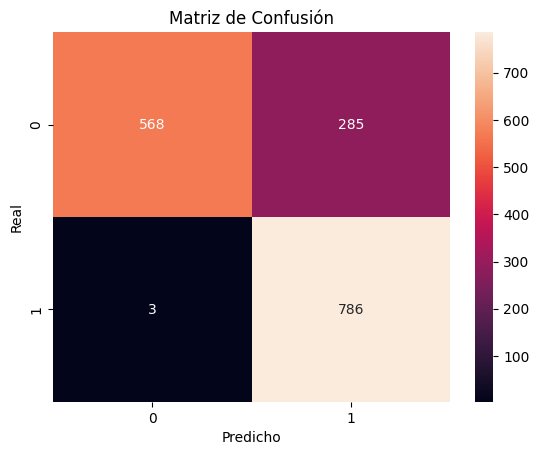

In [40]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

# 20. Gráficos de Accuracy y Loss
Visualizar el progreso del entrenamiento: accuracy y loss en train vs validación.

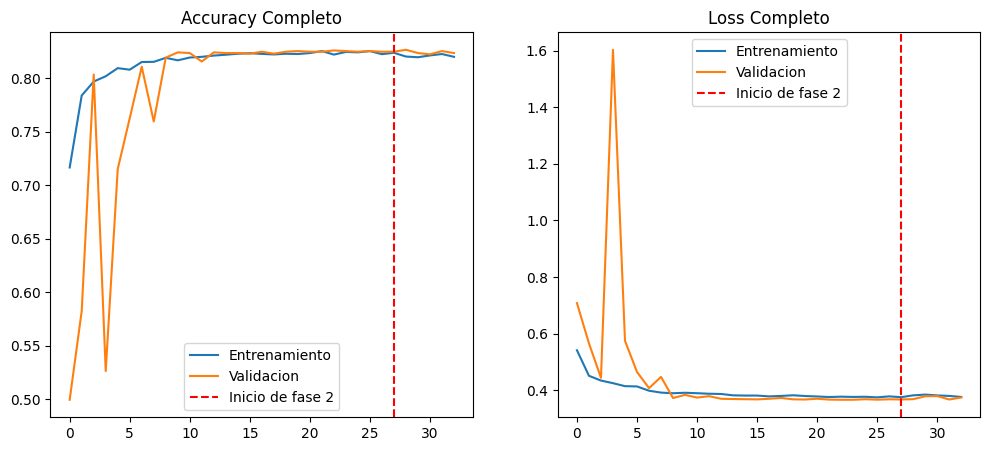

In [ ]:
import matplotlib.pyplot as plt


acc = history.history['accuracy'] + history_fine.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']

loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']

epochs_totales = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_totales, acc, label='Entrenamiento')
plt.plot(epochs_totales, val_acc, label='Validacion')
plt.axvline(x=len(history.history['accuracy']) - 1, color='r', linestyle='--', label='Inicio de fase 2')
plt.title('Accuracy Completo')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_totales, loss, label='Entrenamiento')
plt.plot(epochs_totales, val_loss, label='Validacion')
plt.axvline(x=len(history.history['loss']) - 1, color='r', linestyle='--', label='Inicio de fase 2')
plt.title('Loss Completo')
plt.legend()

plt.show()

In [ ]:

modelo_cnn.save('CNN_personalizada_binaria.keras')